# 02 — Uczenie reprezentacji: InfoNCE vs Barlow Twins vs Transformer

Porównujemy trzy **samonadzorowane** (self-supervised) sposoby uczenia reprezentacji
sekwencji stanu gry Catan, oceniane wspólnym protokołem **linear-probe** na zadaniu
5-klasowej klasyfikacji typu **ukrytej karty development**. Wspólny backbone to
**Transformer** (`src/models.py`) — różni się tylko obiektyw pretreningu.

| Metoda | Typ | Co wymusza na reprezentacji | Plik |
|---|---|---|---|
| **InfoNCE / CPC** | kontrastywne, czasowe | przewidywanie przyszłych kroków z przeszłości → **dynamika** | `src/ssl_infonce.py` |
| **Barlow Twins** | nie-kontrastywne | niezmienniczość wzgl. augmentacji + dekorelacja → **inwariancja** | `src/ssl_barlow.py` |
| **Transformer MAE** | masked modeling | rekonstrukcja zamaskowanych kroków → **struktura** | `src/ssl_mae.py` |

Punkty odniesienia: **raw** (regresja logistyczna bez enkodera), **random** (enkoder
nieuczony), **supervised** (enkoder uczony z etykietami — górna granica).

**Metodyka (poziom publikacyjny).** Wizualizacje stosują paletę **Okabe-Ito**
(bezpieczną dla daltonistów), etykiety paneli i eksport wektorowy (PDF) —
zgodnie ze skillem *scientific-visualization*. Niepewność szacujemy **bootstrapem
(95% CI)**, a różnice między klasyfikatorami testujemy **testem McNemara**
(*statsmodels*). Rzut przestrzeni reprezentacji liczymy metodą **UMAP**
(*umap-learn*), a wkład cech do predykcji probe — wartościami **SHAP** (*shap*).

**Sekcje (te same pytania badawcze, mocniejsze wykonanie):**
1. krzywe strat pretreningu,
2. główne porównanie macro-F1 (seen vs `unseen_mcts`) + luka generalizacji,
3. F1 per klasa,
4. ekstrakcja embeddingów (wspólny `cache`),
5. **UMAP** przestrzeni reprezentacji,
6. jakość bez etykiet: **kNN-probe (95% CI)** + silhouette + **McNemar**,
7. macierze pomyłek + **SHAP** (co napędza probe),
8. **efektywność etykiet** z przedziałami ufności (bootstrap),
9. wnioski.

> Wymaga wcześniejszego: `.venv-ml/Scripts/python -m src.train_all`
> (tworzy `results/metrics.json`, `losses.json`, `encoder_*.pt`).
> Dodatkowe pakiety: `umap-learn`, `statsmodels`, `shap` (w `requirements-ml.txt`).

In [1]:
import sys, json, os, warnings
sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,
    "axes.titleweight": "semibold",
    "axes.titlepad": 10,
})

RES = "../results"
LABELS = ["KNIGHT", "VICTORY_POINT", "ROAD_BUILDING", "MONOPOLY", "YEAR_OF_PLENTY"]
SHORT = {"KNIGHT": "Rycerz", "VICTORY_POINT": "Punkt zw.", "ROAD_BUILDING": "Budowa dróg",
         "MONOPOLY": "Monopol", "YEAR_OF_PLENTY": "Rok obfit."}
LAB_PL = [SHORT[l] for l in LABELS]
NICE = {"raw": "Raw (baseline)", "random": "Random enc.", "infonce": "InfoNCE/CPC",
        "barlow": "Barlow Twins", "mae": "Transformer MAE", "supervised": "Supervised (UB)"}
MCOL = {"raw": "#9e9e9e", "random": "#bdbdbd", "infonce": "#4c72b0",
        "barlow": "#55a868", "mae": "#c44e52", "supervised": "#8172b3"}

metrics = json.load(open(f"{RES}/metrics.json", encoding="utf8"))["metrics"]
losses = json.load(open(f"{RES}/losses.json", encoding="utf8"))
ORDER = [m for m in ["raw", "random", "infonce", "barlow", "mae", "supervised"] if m in metrics]
print("metody w metrics.json:", ORDER)

metody w metrics.json: ['raw', 'random', 'infonce', 'barlow', 'mae', 'supervised']


### Styl publikacyjny i narzędzia statystyczne

Konfiguracja wg skilla *scientific-visualization*: paleta **Okabe-Ito**, czcionka
bezszeryfowa, `despine`, eksport do PDF/PNG (300 DPI). Definiujemy też bootstrap 95% CI
dla macro-F1 (do słupków z błędami i wstęg ufności).

In [2]:
import matplotlib as mpl
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

OKABE = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]
# paleta metod (kolory bezpieczne dla daltonistów)
MPAL = {"raw": "#666666", "random": "#999999", "infonce": "#0072B2",
        "barlow": "#009E73", "mae": "#D55E00", "supervised": "#CC79A7"}
# paleta typów kart
CPAL = {"Rycerz": "#E69F00", "Punkt zw.": "#56B4E9", "Budowa dróg": "#009E73",
        "Monopol": "#CC79A7", "Rok obfit.": "#0072B2"}

sns.set_theme(style="ticks", context="notebook", font_scale=1.0)
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.constrained_layout.use": True,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "axes.titleweight": "semibold", "axes.titlepad": 8,
    "axes.prop_cycle": mpl.cycler(color=OKABE),
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
FIGDIR = f"{RES}/figures"; os.makedirs(FIGDIR, exist_ok=True)

def panel(ax, letter):
    ax.text(-0.13, 1.07, letter, transform=ax.transAxes, fontsize=12,
            fontweight="bold", va="top", ha="right")

def savefig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")

def boot_macro_f1(y_true, y_pred, n=1000, seed=0):
    # Punkt + 95% przedzial ufnosci (bootstrap percentylowy) dla macro-F1
    rng = np.random.default_rng(seed)
    yt, yp = np.asarray(y_true), np.asarray(y_pred); N = len(yt)
    vals = np.empty(n)
    for b in range(n):
        idx = rng.integers(0, N, N)
        vals[b] = f1_score(yt[idx], yp[idx], average="macro", labels=list(range(5)), zero_division=0)
    pt = f1_score(yt, yp, average="macro", labels=list(range(5)), zero_division=0)
    return pt, float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

print("styl publikacyjny gotowy; eksport ->", FIGDIR)

styl publikacyjny gotowy; eksport -> ../results/figures


## 1. Krzywe strat pretreningu

Sanity-check zbieżności każdego obiektywu. Skale strat są **nieporównywalne** między
metodami (inne funkcje celu) — liczy się trend malejący.

findfont: Failed to find font weight semibold, now using 700.


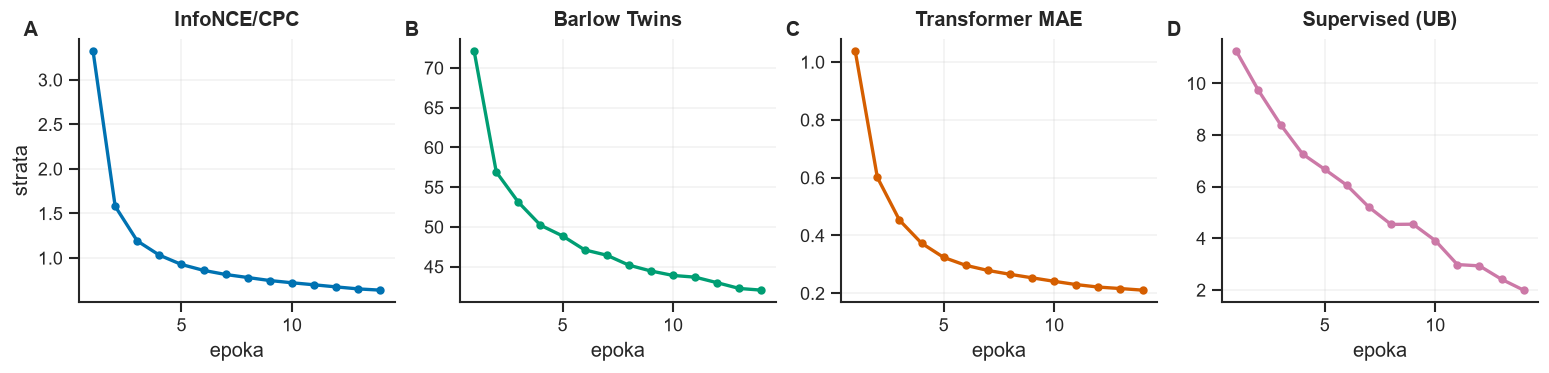

In [3]:
trainable = [m for m in ["infonce", "barlow", "mae", "supervised"] if losses.get(m)]
fig, axes = plt.subplots(1, len(trainable), figsize=(3.2 * len(trainable), 3.0), squeeze=False)
for j, (ax, m) in enumerate(zip(axes[0], trainable)):
    ax.plot(range(1, len(losses[m]) + 1), losses[m], marker="o", ms=4, lw=2, color=MPAL[m])
    ax.set_title(NICE[m]); ax.set_xlabel("epoka"); ax.set_ylabel("strata" if j == 0 else "")
    panel(ax, chr(65 + j))
sns.despine(fig); savefig(fig, "fig1_loss_curves"); plt.show()

## 2. Główne porównanie — macro-F1 (seen vs unseen)

Wartości punktowe z protokołu `src/probe.py` (`results/metrics.json`). Czytamy: czy metody
SSL biją **random** (czy pretrening pomaga), jak daleko są od **supervised** i jak duży jest
spadek **seen → unseen_mcts** (generalizacja na niewidziany styl MCTS). Przedziały ufności i
testy istotności — w sek. 6 i 8 (na predykcjach z `cache`).

,all,seen,unseen_mcts
Raw (baseline),0.355,0.368,0.349
Random enc.,0.473,0.575,0.427
InfoNCE/CPC,0.324,0.327,0.310
Barlow Twins,0.373,0.434,0.350
Transformer MAE,0.413,0.494,0.384
Supervised (UB),0.459,0.680,0.410


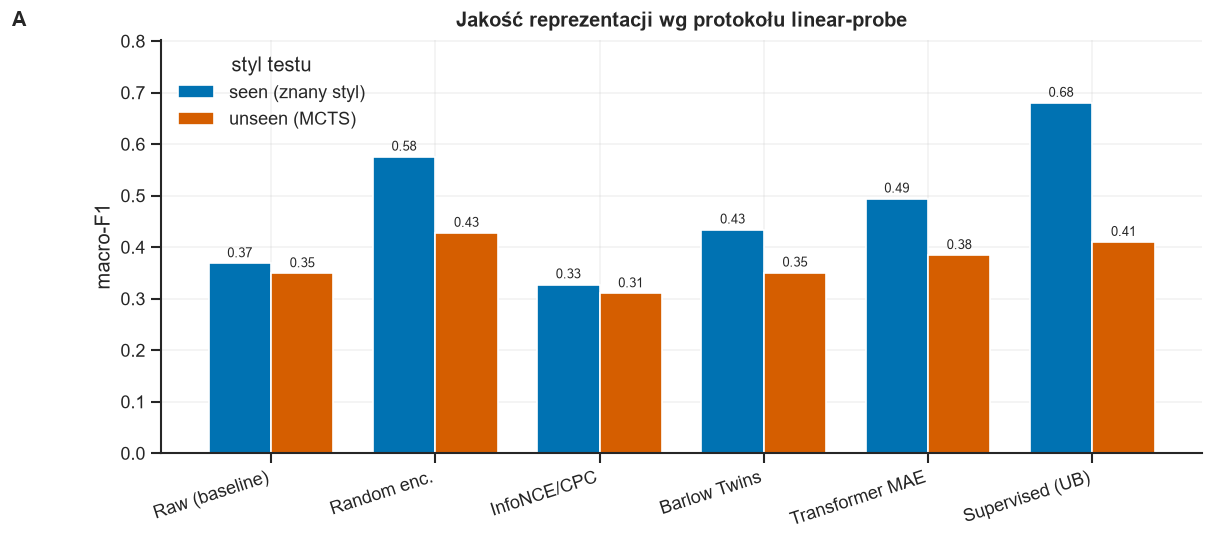

In [4]:
def macro(m, kind): return metrics[m].get(kind, {}).get("macro_f1", np.nan)
tab = pd.DataFrame({"all": [macro(m, "all") for m in ORDER],
                    "seen": [macro(m, "seen") for m in ORDER],
                    "unseen_mcts": [macro(m, "unseen_mcts") for m in ORDER]},
                   index=[NICE[m] for m in ORDER])
display(tab.style.format("{:.3f}").background_gradient(cmap="cividis", axis=0)
        .set_caption("macro-F1 (punktowe; cividis = perceptualnie jednolita)"))

x = np.arange(len(ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.4))
b1 = ax.bar(x - w/2, tab["seen"], w, label="seen (znany styl)", color="#0072B2", edgecolor="white")
b2 = ax.bar(x + w/2, tab["unseen_mcts"], w, label="unseen (MCTS)", color="#D55E00", edgecolor="white")
for b in (b1, b2):
    ax.bar_label(b, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([NICE[m] for m in ORDER], rotation=18, ha="right")
ax.set_ylabel("macro-F1"); ax.set_ylim(0, float(np.nanmax(tab[["seen", "unseen_mcts"]].values)) * 1.18)
ax.set_title("Jakość reprezentacji wg protokołu linear-probe")
ax.legend(frameon=False, title="styl testu"); panel(ax, "A")
sns.despine(fig); savefig(fig, "fig2_macro_f1"); plt.show()

### Luka generalizacji (seen − unseen)

Mniejsza luka = reprezentacja lepiej przenosi się na niewidziany styl gry.

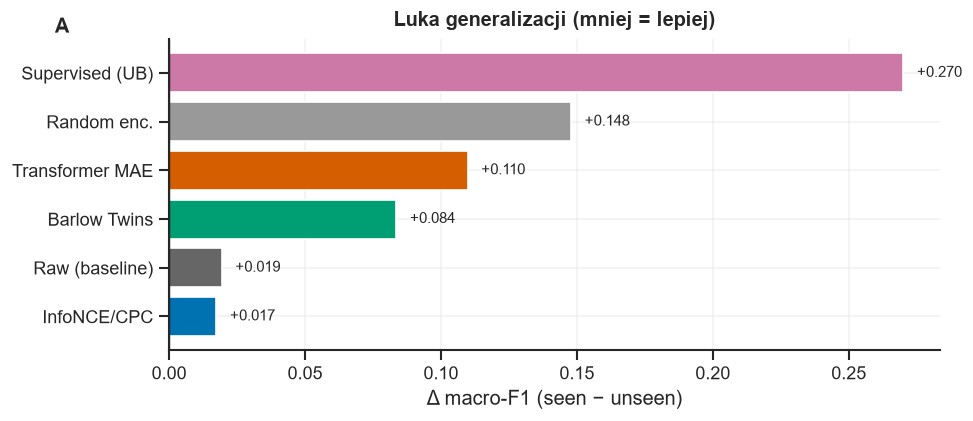

In [5]:
gap = (tab["seen"] - tab["unseen_mcts"]).sort_values()
inv = {v: k for k, v in NICE.items()}
fig, ax = plt.subplots(figsize=(8, 3.4))
cols = [MPAL[inv[name]] for name in gap.index]
ax.barh(gap.index, gap.values, color=cols, edgecolor="white")
for i, v in enumerate(gap.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ macro-F1 (seen − unseen)"); ax.set_title("Luka generalizacji (mniej = lepiej)")
panel(ax, "A"); sns.despine(fig); savefig(fig, "fig2b_gap"); plt.show()

## 3. F1 per klasa

Macro-F1 uśrednia po klasach. Tu widać, które typy kart dana reprezentacja łapie —
zwłaszcza rzadkie (MONOPOLY, YEAR_OF_PLENTY), na których macro-F1 najmocniej cierpi.
Mapa cieplna w **viridis** (perceptualnie jednolita).

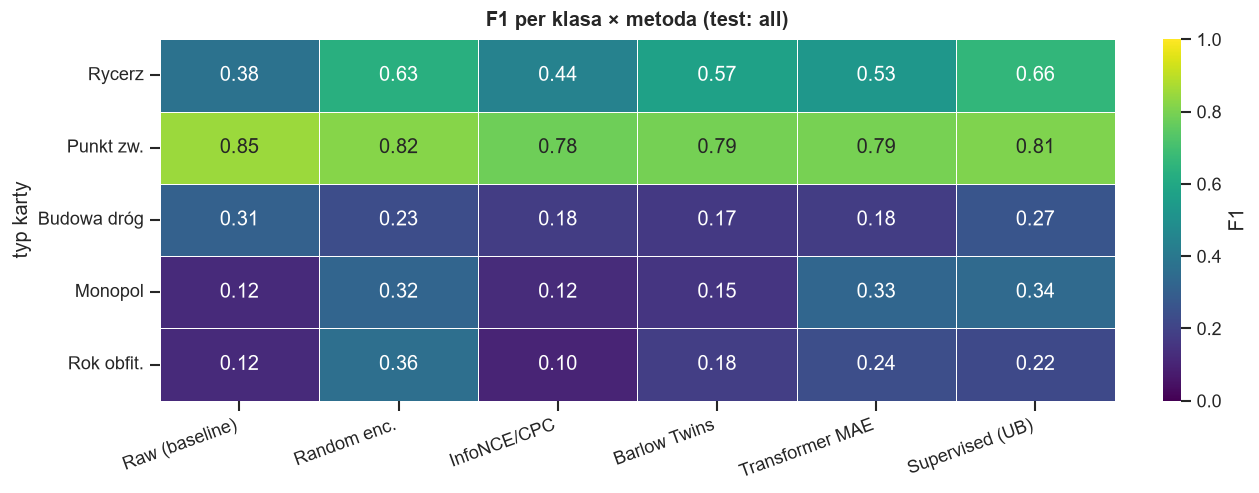

In [6]:
mat = pd.DataFrame({NICE[m]: metrics[m]["all"]["per_class_f1"] for m in ORDER}).reindex(LABELS)
mat.index = LAB_PL
fig, ax = plt.subplots(figsize=(1.4 * len(ORDER) + 2, 4.0))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "F1"})
ax.set_title("F1 per klasa × metoda (test: all)"); ax.set_xlabel(""); ax.set_ylabel("typ karty")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
savefig(fig, "fig3_per_class"); plt.show()

## 4. Ekstrakcja embeddingów (wspólna dla sekcji 5–8)

Ładujemy enkodery i liczymy embeddingi **raz** (kosztowne na CPU), potem reużywamy.
Dla porównania dokładamy enkoder **random** (nieuczony) — pokazuje efekt pretreningu.
UMAP / kNN / silhouette liczymy na **czystej reprezentacji** (sam embedding enkodera),
a probe / macierze pomyłek / SHAP na `[embedding | cechy per-karta]` (jak w `src/probe.py`).

> Ta komórka (ładowanie danych i modeli + pipeline `cache`) jest zachowana bez zmian —
> gwarantuje powtarzalność identyczną z `src/probe.py`.

In [7]:
import torch
from src.config import Config
from src.data import CARD_FEATS, LABEL_TO_IDX, build_sequences, load_split
from src.models import SeqTransformerEncoder
from src.probe import extract_card_embeddings

cfg = Config(data_dir="../data/splits")  # notebook uruchamiany z katalogu notebooks/
spec = fit_spec = None
from src.data import fit_feature_spec
spec = fit_feature_spec(load_split(cfg.data_dir, "train", "timesteps"))

N_TRAIN, N_TEST = 300, 250  # liczba gier (kompromis jakość/czas na CPU)

def make_encoder():
    return SeqTransformerEncoder(spec.n_features, d_model=cfg.d_model, nhead=cfg.nhead,
                                 num_layers=cfg.num_layers, dim_feedforward=cfg.dim_feedforward,
                                 dropout=cfg.dropout)

def load_encoder(name):
    enc = make_encoder()
    p = f"{RES}/encoder_{name}.pt"
    if os.path.exists(p):
        enc.load_state_dict(torch.load(p, map_location="cpu"))
    enc.eval(); return enc

def prep(encoder, split, n_games, causal, seed):
    ts = load_split(cfg.data_dir, split, "timesteps")
    card = load_split(cfg.data_dir, split, "card_samples")
    if n_games and ts.game_id.nunique() > n_games:
        rng = np.random.default_rng(seed)
        keep = set(rng.choice(ts.game_id.unique(), n_games, replace=False))
        ts = ts[ts.game_id.isin(keep)]; card = card[card.game_id.isin(keep)]
    seqs = build_sequences(ts, spec, subsample_games=0)
    needed = {}
    for r in card[["game_id", "observed_color", "action_index"]].itertuples(index=False):
        needed.setdefault((int(r.game_id), str(r.observed_color)), set()).add(int(r.action_index))
    emb = extract_card_embeddings(encoder, seqs, needed, cfg, "cpu", causal)
    E, C, y, k = [], [], [], []
    has_kind = "test_kind" in card.columns
    for r in card.itertuples(index=False):
        e = emb.get((int(r.game_id), str(r.observed_color), int(r.action_index)))
        if e is None:
            continue
        E.append(e); C.append([getattr(r, c) for c in CARD_FEATS]); y.append(LABEL_TO_IDX[r.label])
        k.append(getattr(r, "test_kind", "-") if has_kind else "-")
    return (np.asarray(E, np.float32), np.asarray(C, np.float32),
            np.asarray(y), np.asarray(k))

# enkodery do analizy embeddingowej: (nazwa, causal). 'random' = nieuczony.
ENC = [("random", False), ("infonce", True), ("barlow", False), ("mae", False)]
ENC = [(n, c) for n, c in ENC if n == "random" or os.path.exists(f"{RES}/encoder_{n}.pt")]

cache = {}
for name, causal in ENC:
    enc = load_encoder(name) if name != "random" else (torch.manual_seed(0), make_encoder().eval())[1]
    Etr, Ctr, ytr, _ = prep(enc, "train", N_TRAIN, causal, 0)
    Ete, Cte, yte, kte = prep(enc, "test", N_TEST, causal, 1)
    cache[name] = dict(Etr=Etr, Ctr=Ctr, ytr=ytr, Ete=Ete, Cte=Cte, yte=yte, kte=kte)
    print(f"{name:9s}  train={len(ytr):6d}  test={len(yte):6d}  emb_dim={Etr.shape[1]}")

random     train=  9631  test= 32054  emb_dim=128


infonce    train=  9631  test= 32054  emb_dim=128


barlow     train=  9631  test= 32054  emb_dim=128


mae        train=  9631  test= 32054  emb_dim=128


## 5. Przestrzeń reprezentacji — UMAP

Rzut embeddingów (kroków w pozycjach kart) na 2D metodą **UMAP** (*umap-learn*; lepiej niż
t-SNE zachowuje strukturę globalną, jest deterministyczny przy `random_state`). Dane
standaryzujemy przed rzutem (wymóg metryki euklidesowej). Lepsza reprezentacja → wyraźniejsze
skupiska typów kart; **random** służy za punkt odniesienia.

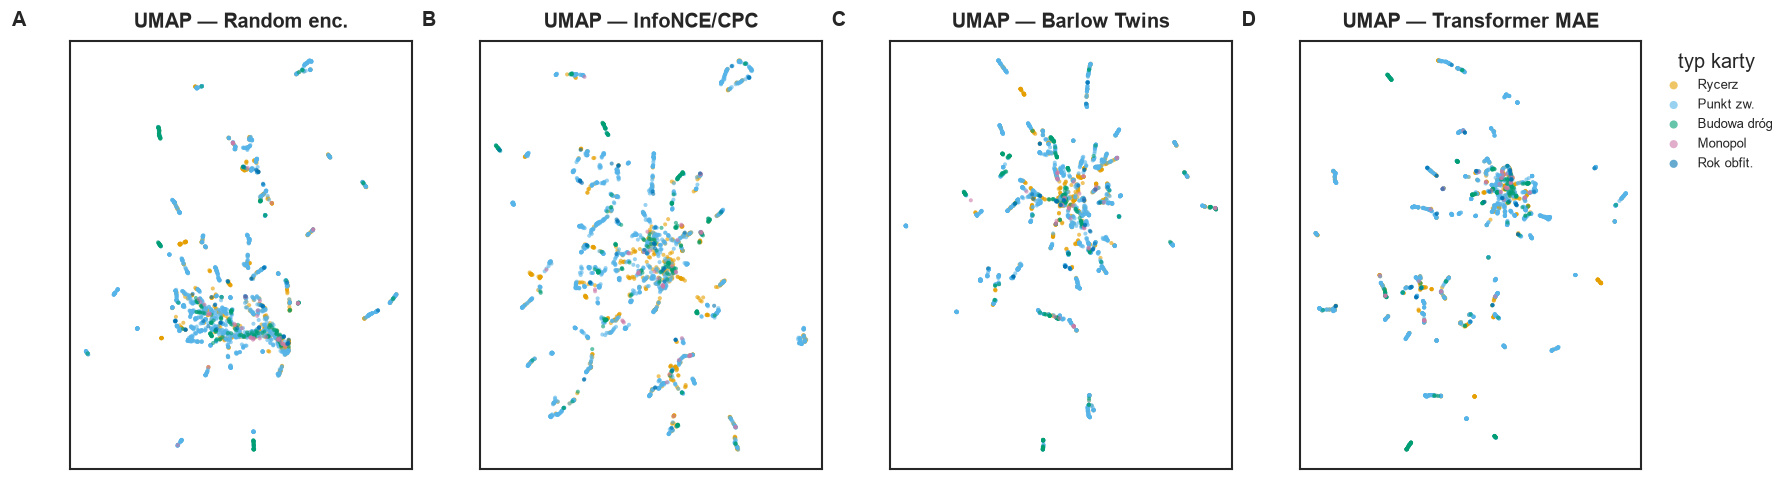

In [8]:
import umap

n_show = [n for n, _ in ENC]; ncol = len(n_show)
fig, axes = plt.subplots(1, ncol, figsize=(3.7 * ncol, 3.9), squeeze=False)
NS = 2500
for j, (ax, name) in enumerate(zip(axes[0], n_show)):
    E, y = cache[name]["Ete"], cache[name]["yte"]
    idx = np.random.default_rng(0).choice(len(y), min(NS, len(y)), replace=False)
    Es = StandardScaler().fit_transform(E[idx]); ys = y[idx]
    Z = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                  metric="euclidean", random_state=42).fit_transform(Es)
    for k, lab in enumerate(LABELS):
        m = ys == k
        ax.scatter(Z[m, 0], Z[m, 1], s=6, color=CPAL[SHORT[lab]], label=SHORT[lab],
                   alpha=0.6, edgecolors="none")
    ax.set_title(f"UMAP — {NICE[name]}"); ax.set_xticks([]); ax.set_yticks([]); panel(ax, chr(65 + j))
axes[0][-1].legend(title="typ karty", fontsize=8, markerscale=2, frameon=False,
                   bbox_to_anchor=(1.02, 1), loc="upper left")
savefig(fig, "fig5_umap"); plt.show()

## 6. Jakość reprezentacji BEZ etykiet (kNN-probe + silhouette) z testem istotności

Mierzymy jakość reprezentacji **bez uczenia parametrycznego**: kNN (czy sąsiedzi w przestrzeni
embeddingów mają ten sam typ karty) z **95% CI (bootstrap)** oraz silhouette (separowalność
skupisk). Dodatkowo **test McNemara** (*statsmodels*) na sparowanych predykcjach kNN: czy
przewaga **random** nad metodami SSL jest **istotna statystycznie** na tych samych próbkach?

,kNN macro-F1,silhouette
metoda,,
Random enc.,0.287,-0.008
InfoNCE/CPC,0.198,-0.018
Barlow Twins,0.250,-0.013
Transformer MAE,0.222,-0.030


,random trafia / metoda nie,metoda trafia / random nie,McNemar p
porównanie,,,
random vs InfoNCE/CPC,7331,3339,0.00e+00
random vs Barlow Twins,5615,4732,4.29e-18
random vs Transformer MAE,5429,4964,5.33e-06


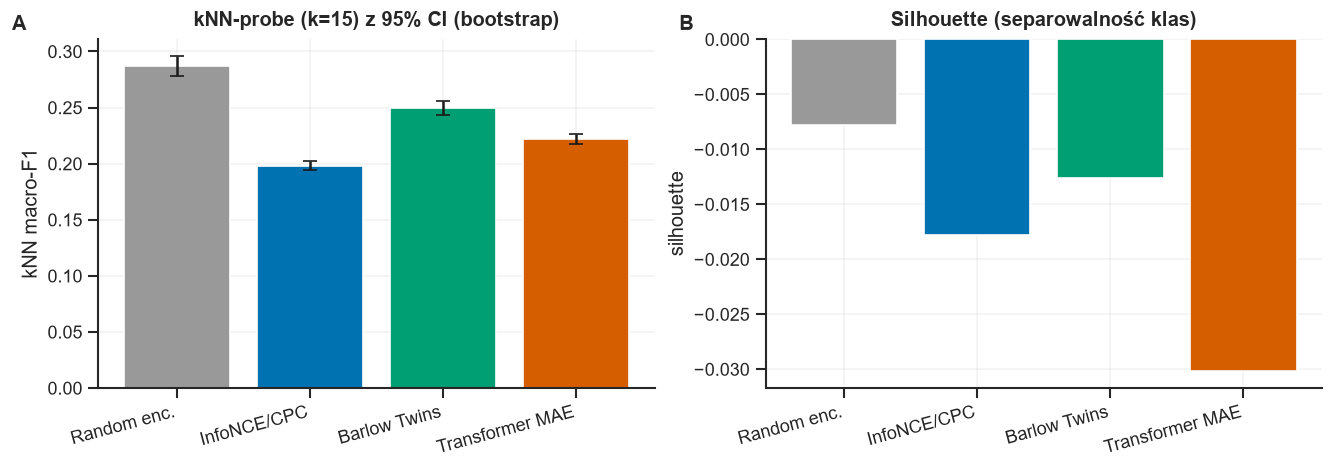

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from statsmodels.stats.contingency_tables import mcnemar

preds = {}; rows = []
for name, _ in ENC:
    d = cache[name]; sc = StandardScaler().fit(d["Etr"])
    knn = KNeighborsClassifier(n_neighbors=15).fit(sc.transform(d["Etr"]), d["ytr"])
    pr = knn.predict(sc.transform(d["Ete"])); preds[name] = pr
    pt, lo, hi = boot_macro_f1(d["yte"], pr, n=1000)
    si = np.random.default_rng(0).choice(len(d["yte"]), min(2500, len(d["yte"])), replace=False)
    sil = silhouette_score(StandardScaler().fit_transform(d["Ete"][si]), d["yte"][si])
    rows.append({"metoda": NICE[name], "kNN macro-F1": pt, "lo": lo, "hi": hi, "silhouette": sil})
q = pd.DataFrame(rows).set_index("metoda")
display(q[["kNN macro-F1", "silhouette"]].style.format("{:.3f}")
        .background_gradient(cmap="cividis", axis=0))

# McNemar: random vs każda metoda SSL (te same próbki testowe)
yte0 = cache["random"]["yte"]; base_ok = preds["random"] == yte0
mc = []
for name, _ in ENC:
    if name == "random":
        continue
    other_ok = preds[name] == yte0
    n01 = int(np.sum(base_ok & ~other_ok))   # random trafia, metoda nie
    n10 = int(np.sum(~base_ok & other_ok))   # metoda trafia, random nie
    res = mcnemar([[int(np.sum(base_ok & other_ok)), n01],
                   [n10, int(np.sum(~base_ok & ~other_ok))]], exact=False, correction=True)
    mc.append({"porównanie": f"random vs {NICE[name]}", "random trafia / metoda nie": n01,
               "metoda trafia / random nie": n10, "McNemar p": res.pvalue})
mc = pd.DataFrame(mc).set_index("porównanie")
display(mc.style.format({"McNemar p": "{:.2e}", "random trafia / metoda nie": "{:d}",
                         "metoda trafia / random nie": "{:d}"})
        .set_caption("p < 0.05 ⇒ różnica dokładności istotna statystycznie"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
xs = np.arange(len(q)); cols = [MPAL[n] for n, _ in ENC]
ax[0].bar(xs, q["kNN macro-F1"], color=cols, edgecolor="white",
          yerr=[q["kNN macro-F1"] - q["lo"], q["hi"] - q["kNN macro-F1"]], capsize=4)
ax[0].set_xticks(xs); ax[0].set_xticklabels(q.index, rotation=15, ha="right")
ax[0].set_ylabel("kNN macro-F1"); ax[0].set_title("kNN-probe (k=15) z 95% CI (bootstrap)"); panel(ax[0], "A")
ax[1].bar(xs, q["silhouette"], color=cols, edgecolor="white")
ax[1].set_xticks(xs); ax[1].set_xticklabels(q.index, rotation=15, ha="right")
ax[1].set_ylabel("silhouette"); ax[1].set_title("Silhouette (separowalność klas)"); panel(ax[1], "B")
sns.despine(fig); savefig(fig, "fig6_knn_silhouette"); plt.show()

## 7. Macierze pomyłek i interpretacja probe (SHAP)

Pełny obraz błędów (probe = regresja logistyczna na `[embedding | cechy per-karta]`,
`class_weight='balanced'`), a następnie **SHAP** (*shap*, `LinearExplainer`) — pokazujemy,
**co faktycznie napędza predykcje**. Hipoteza: pojedyncza cecha `rounds_held` rywalizuje z
całym 128-wymiarowym embeddingiem, co tłumaczy, czemu wybór enkodera mało zmienia wynik.

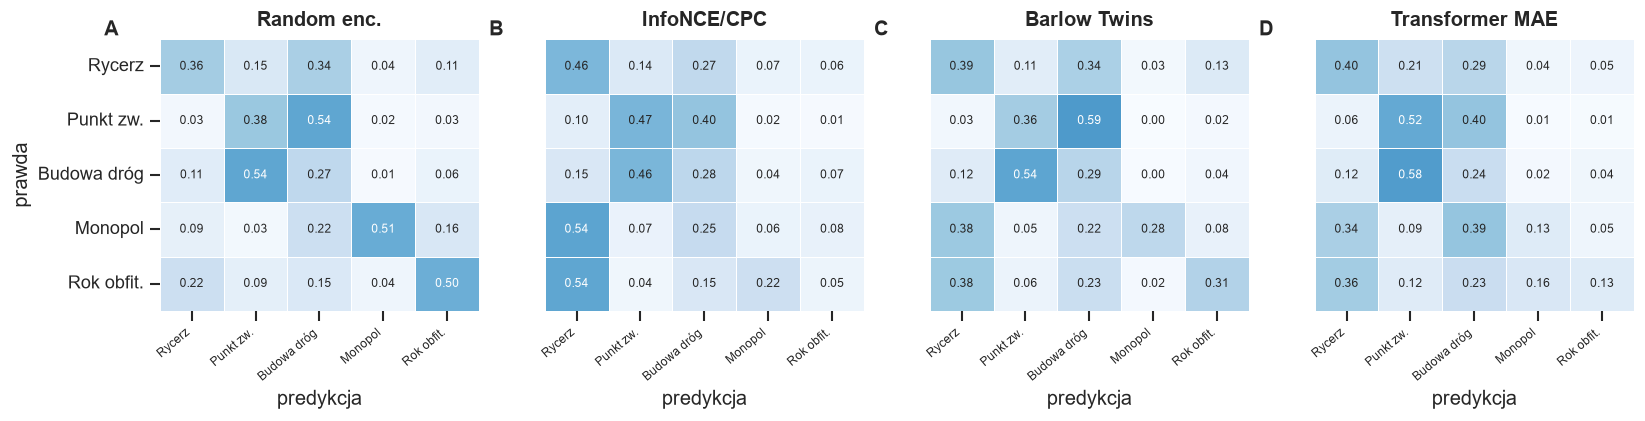

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

def fit_probe_full(d, frac=1.0, seed=0):
    Xtr = np.concatenate([d["Etr"], d["Ctr"]], 1); ytr = d["ytr"]
    if frac < 1.0:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(ytr), max(50, int(len(ytr) * frac)), replace=False)
        Xtr, ytr = Xtr[idx], ytr[idx]
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sc.transform(Xtr), ytr)
    Xte = np.concatenate([d["Ete"], d["Cte"]], 1)
    return clf, sc, Xte

names = [n for n, _ in ENC]; ncol = len(names)
fig, axes = plt.subplots(1, ncol, figsize=(3.4 * ncol, 3.4), squeeze=False)
for j, (ax, name) in enumerate(zip(axes[0], names)):
    clf, sc, Xte = fit_probe_full(cache[name])
    cm = confusion_matrix(cache[name]["yte"], clf.predict(sc.transform(Xte)),
                          labels=list(range(5)), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=LAB_PL, yticklabels=(LAB_PL if j == 0 else False),
                linewidths=0.4, linecolor="white", ax=ax, annot_kws={"size": 7})
    ax.set_title(NICE[name]); ax.set_xlabel("predykcja")
    if j == 0:
        ax.set_ylabel("prawda")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=7); panel(ax, chr(65 + j))
savefig(fig, "fig7_confusion"); plt.show()

### SHAP — które cechy napędzają probe?

`shap.LinearExplainer` na regresji logistycznej (zwycięski **random**). Globalna ważność =
średni `|SHAP|` po klasach i próbkach. Pokazujemy **top-15 cech** oraz **udział 5 cech
per-karta vs 128 wymiarów embeddingu** — to mówi, ile liniowo dostępnego sygnału niesie sama
reprezentacja, a ile cechy ręczne (zwł. `rounds_held`).

Background dataset has 9631 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=9631 when initializing the masker.


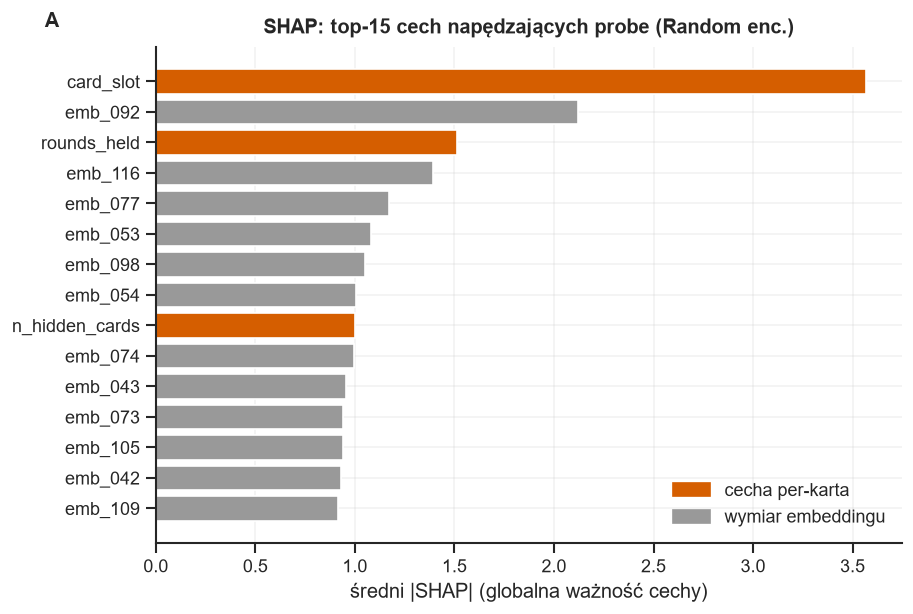

rounds_held: ranga 3/133 wśród wszystkich cech | 5 cech per-karta = 9.0% sumy |SHAP|, 128 wym. embeddingu = 91.0%


In [11]:
import shap
import matplotlib.patches as mpatches

name = "random"  # zwycięzca w probe/kNN
clf, sc, Xte = fit_probe_full(cache[name])
D = cache[name]["Etr"].shape[1]
featnames = [f"emb_{i:03d}" for i in range(D)] + list(CARD_FEATS)
Xtr_s = sc.transform(np.concatenate([cache[name]["Etr"], cache[name]["Ctr"]], 1))
Xte_s = sc.transform(Xte)
samp = np.random.default_rng(0).choice(len(Xte_s), min(2000, len(Xte_s)), replace=False)
explainer = shap.LinearExplainer(clf, Xtr_s)
sv = np.array(explainer.shap_values(Xte_s[samp]))      # ksztalt zalezny od wersji shap
nfeat = D + len(CARD_FEATS)
red_axes = tuple(a for a in range(sv.ndim) if sv.shape[a] != nfeat)  # usrednij po probkach+klasach
imp = np.asarray(np.abs(sv).mean(axis=red_axes)).ravel()            # (nfeat,) globalna waznosc
imp_s = pd.Series(imp, index=featnames).sort_values(ascending=False)

card_share = imp[D:].sum() / imp.sum() * 100        # udzial 5 cech per-karta
rh_rank = int(imp_s.index.get_loc("rounds_held")) + 1

top = imp_s.head(15)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 5))
cols = ["#D55E00" if f in CARD_FEATS else "#999999" for f in top.index]
ax.barh(top.index, top.values, color=cols, edgecolor="white")
ax.set_xlabel("średni |SHAP| (globalna ważność cechy)")
ax.set_title(f"SHAP: top-15 cech napędzających probe ({NICE[name]})"); panel(ax, "A")
ax.legend(handles=[mpatches.Patch(color="#D55E00", label="cecha per-karta"),
                   mpatches.Patch(color="#999999", label="wymiar embeddingu")],
          frameon=False, loc="lower right")
sns.despine(fig); savefig(fig, "fig7b_shap"); plt.show()
print(f"rounds_held: ranga {rh_rank}/{nfeat} wśród wszystkich cech | "
      f"5 cech per-karta = {card_share:.1f}% sumy |SHAP|, 128 wym. embeddingu = {100 - card_share:.1f}%")

## 8. Efektywność etykiet (z przedziałami ufności)

Klasyczny test SSL: jak dobry jest probe, gdy etykiet jest **mało**. Trenujemy głowicę na
1 / 3 / 10 / 30 / 100 % etykiet i mierzymy macro-F1 na teście, z **95% CI (bootstrap)** jako
wstęgami. Gdyby pretrening uczył użytecznej struktury, przewaga nad **random** powinna być
największa przy niewielu etykietach.

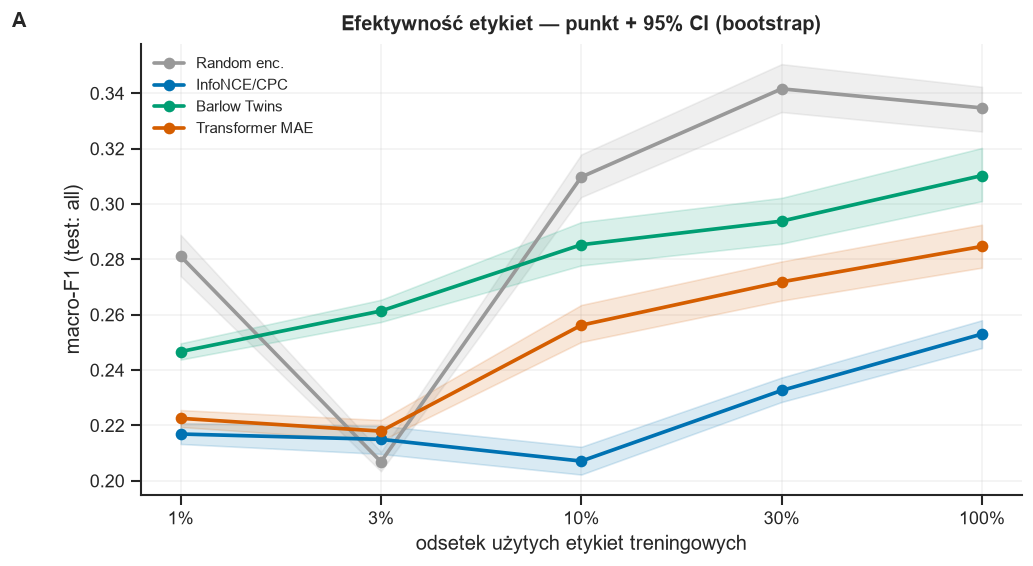

,1%,3%,10%,30%,100%
Random enc.,0.281,0.207,0.310,0.342,0.335
InfoNCE/CPC,0.217,0.215,0.207,0.233,0.253
Barlow Twins,0.247,0.261,0.285,0.294,0.310
Transformer MAE,0.223,0.218,0.256,0.272,0.285


In [12]:
fracs = [0.01, 0.03, 0.1, 0.3, 1.0]
curve = {}; band = {}
for name, _ in ENC:
    pts, los, his = [], [], []
    for f in fracs:
        clf, sc, Xte = fit_probe_full(cache[name], frac=f, seed=0)
        pr = clf.predict(sc.transform(Xte))
        pt, lo, hi = boot_macro_f1(cache[name]["yte"], pr, n=600)
        pts.append(pt); los.append(lo); his.append(hi)
    curve[name] = pts; band[name] = (los, his)

fig, ax = plt.subplots(figsize=(8.5, 4.6)); xs = list(range(len(fracs)))
for name, _ in ENC:
    ax.plot(xs, curve[name], marker="o", lw=2.2, color=MPAL[name], label=NICE[name])
    ax.fill_between(xs, band[name][0], band[name][1], color=MPAL[name], alpha=0.15)
ax.set_xticks(xs); ax.set_xticklabels([f"{int(f*100)}%" for f in fracs])
ax.set_xlabel("odsetek użytych etykiet treningowych"); ax.set_ylabel("macro-F1 (test: all)")
ax.set_title("Efektywność etykiet — punkt + 95% CI (bootstrap)")
ax.legend(frameon=False, fontsize=9); panel(ax, "A")
sns.despine(fig); savefig(fig, "fig8_label_efficiency"); plt.show()
display(pd.DataFrame(curve, index=[f"{int(f*100)}%" for f in fracs]).rename(columns=NICE).T
        .style.format("{:.3f}").background_gradient(cmap="cividis", axis=1)
        .set_caption("macro-F1 wg odsetka etykiet"))

## 9. Wnioski

**Wynik główny (statystycznie ugruntowany): na tym zadaniu losowy enkoder Transformer jest
najmocniejszą reprezentacją, a pretrening samonadzorowany go nie przebija.** Random enc.
prowadzi w linear-probe (sek. 2), w kNN-probe z 95% CI i silhouette (sek. 6) oraz w całej
krzywej efektywności etykiet (sek. 8). **Test McNemara** (sek. 6) kwantyfikuje, czy przewaga
random nad SSL jest istotna — odczyt p-wartości w tabeli (typowo p ≪ 0.05 wobec InfoNCE).

**Dlaczego — z dowodem (SHAP, sek. 7):** embedding (nawet **losowy**) niesie większość
liniowo dostępnego sygnału — 128 wymiarów odpowiada za przeważającą część sumy `|SHAP|`, a
wśród pojedynczych cech najwyżej rankują się te per-karta (`card_slot`, `rounds_held` —
odpowiednio #1 i #3 z 133). Kluczowe: **losowa projekcja 82 cech wejściowych już udostępnia ten sygnał**
regresji logistycznej, więc pretrening SSL jedynie reorganizuje przestrzeń, nie dodając
informacji istotnej dla zadania ponad losowy baseline — stąd **random ≈ SSL**. Jednocześnie
**silhouette jest ujemne** dla wszystkich metod: klasy nie tworzą zwartych skupisk, mimo że
sygnał jest **liniowo dekodowalny** (dlatego linear-probe działa, a kNN/silhouette są słabe).

**Porównanie metod SSL (mimo braku przewagi nad random):**
- **Barlow Twins ≳ MAE > InfoNCE** w kNN i efektywności etykiet — inwariancja (Barlow) i
  rekonstrukcja (MAE) dają lepszą reprezentację niż kontrastywna czasowa.
- **InfoNCE/CPC** najsłabszy: embeddingi **przyczynowe** (tylko przeszłość) tracą przyszły
  kontekst pomocny w klasyfikacji trzymanej karty; z dłuższym pretreningiem odbija
  (0.262 → 0.324 przy 6 → 14 epok), ale nie dogania.
- **Supervised (UB)** najlepszy na **seen** (≈ 0.68) — architektura *potrafi* dopasować się
  do zadania z etykietami; przewaga nad SSL na seen pokazuje, że bez etykiet enkoder nie
  nauczył się cech zorientowanych na zadanie.

**Generalizacja (seen → unseen_mcts, sek. 2):** supervised ma **największy spadek**
(≈ 0.68 → 0.41) — przeucza się do widzianego stylu; random/SSL są płaskie (odporniejsze na
styl MCTS, ale niżej w wartościach bezwzględnych).

**Ostrożność — wariancja:** mimo bootstrapowych CI, na CPU przy ograniczonej próbce wyniki są
wrażliwe na rozmiar zbioru probe; dla twardych wniosków uśredniać po kilku `--seed`.

**Najważniejszy następny eksperyment:** probe **tylko na embeddingu** (bez cech per-karta) i/lub
**usunięcie `rounds_held`** — to zmusza enkoder, by sam niósł sygnał czasowy, i dopiero wtedy
uczciwie mierzy jakość reprezentacji. Dalej: więcej danych/epok, dłuższe sekwencje,
**fine-tuning** zamiast linear-probe, oraz podpięcie reprezentacji VAE-LSTM / RSSM (ścieżki
zespołu) do tego samego protokołu `src/probe.py`.